===== FEATURE IMPORTANCE =====


,Feature,Importance
0,Torque_Nm,1612
1,Tool_wear_min,1274
2,Rotational_speed_rpm,1131
3,Process_temperature_K,925
4,Air_temperature_K,912
5,Type_L,84
6,Type_M,62


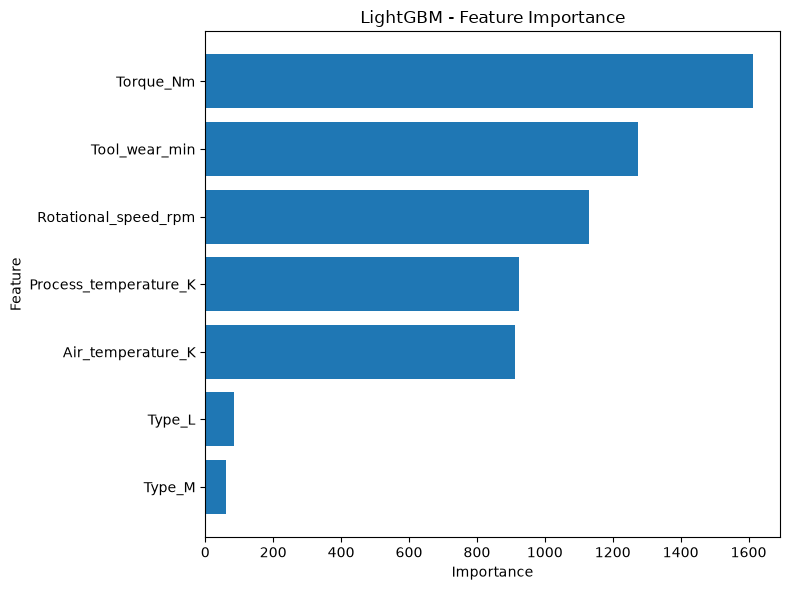

In [28]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("===== FEATURE IMPORTANCE =====")
display(importance)

plt.figure(figsize=(8, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("LightGBM - Feature Importance")

plt.tight_layout()
plt.show()

===== CONFUSION MATRIX =====
[[1903   29]
 [  16   52]]


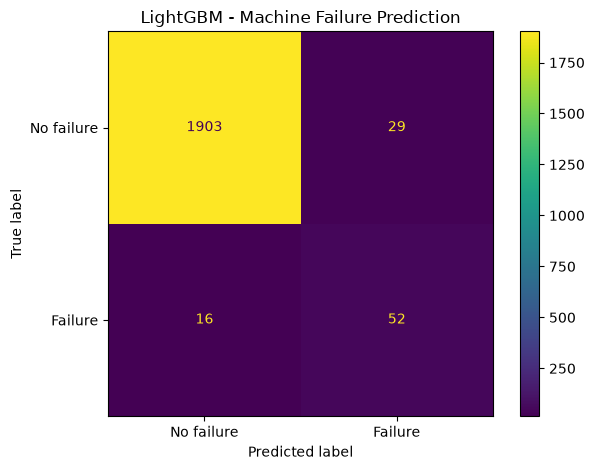

In [27]:
cm = confusion_matrix(y_test, y_pred)

print("===== CONFUSION MATRIX =====")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No failure", "Failure"]
)

disp.plot()

plt.title("LightGBM - Machine Failure Prediction")
plt.tight_layout()
plt.show()

In [26]:
print("===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No failure", "Failure"],
        zero_division=0
    )
)

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

  No failure       0.99      0.98      0.99      1932
     Failure       0.64      0.76      0.70        68

    accuracy                           0.98      2000
   macro avg       0.82      0.87      0.84      2000
weighted avg       0.98      0.98      0.98      2000



In [25]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("===== ĐÁNH GIÁ MÔ HÌNH =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

===== ĐÁNH GIÁ MÔ HÌNH =====
Accuracy : 0.9775
Precision: 0.6420
Recall   : 0.7647
F1-score : 0.6980


In [24]:
y_pred = model.predict(X_test)

print("===== KẾT QUẢ DỰ ĐOÁN =====")
print("Số mẫu dự đoán:", len(y_pred))

print("\n20 kết quả dự đoán đầu tiên:")
print(y_pred[:20])

print("\n20 giá trị thực tế đầu tiên:")
print(y_test.iloc[:20].values)

===== KẾT QUẢ DỰ ĐOÁN =====
Số mẫu dự đoán: 2000

20 kết quả dự đoán đầu tiên:
[0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0]

20 giá trị thực tế đầu tiên:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]


In [23]:
print("===== HUẤN LUYỆN LIGHTGBM =====")

model.fit(
    X_train,
    y_train
)

print("Huấn luyện mô hình thành công!")

===== HUẤN LUYỆN LIGHTGBM =====
Huấn luyện mô hình thành công!


In [22]:
model = LGBMClassifier(
    objective="binary",
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    random_state=101,
    verbosity=-1
)

print("Đã khởi tạo mô hình LightGBM thành công!")

Đã khởi tạo mô hình LightGBM thành công!


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=101,
    stratify=y
)

print("===== CHIA TRAIN / TEST =====")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

===== CHIA TRAIN / TEST =====
X_train: (8000, 7)
X_test : (2000, 7)
y_train: (8000,)
y_test : (2000,)


In [20]:
# One-hot encoding biến Type
X = pd.get_dummies(
    X,
    columns=["Type"],
    drop_first=True,
    dtype=int
)

# Làm sạch tên feature để LightGBM không lỗi ký tự đặc biệt
X.columns = (
    X.columns
    .str.replace(r"[^A-Za-z0-9_]+", "_", regex=True)
    .str.strip("_")
)

print("===== DỮ LIỆU SAU KHI MÃ HÓA =====")
display(X.head())

print("\nTên các feature:")
print(X.columns.tolist())

print("\nX shape:", X.shape)

===== DỮ LIỆU SAU KHI MÃ HÓA =====


,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,1
1,298.2,308.7,1408,46.3,3,1,0
2,298.1,308.5,1498,49.4,5,1,0
3,298.2,308.6,1433,39.5,7,1,0
4,298.2,308.7,1408,40.0,9,1,0



Tên các feature:
['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Type_L', 'Type_M']

X shape: (10000, 7)


In [19]:
X = df[
    [
        "Type",
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]"
    ]
].copy()

y = df["Machine failure"].copy()

print("===== X - FEATURES =====")
display(X.head())

print("\n===== y - TARGET =====")
display(y.head())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

===== X - FEATURES =====


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9



===== y - TARGET =====


0    0
1    0
2    0
3    0
4    0
Name: Machine failure, dtype: int64


X shape: (10000, 6)
y shape: (10000,)


In [18]:
# Xóa các dòng trùng lặp
df = df.drop_duplicates().copy()
df = df.reset_index(drop=True)

print("===== SAU KHI LÀM SẠCH =====")
print("Kích thước:", df.shape)
print("Tổng giá trị thiếu:", df.isnull().sum().sum())
print("Số dòng trùng:", df.duplicated().sum())

===== SAU KHI LÀM SẠCH =====
Kích thước: (10000, 14)
Tổng giá trị thiếu: 0
Số dòng trùng: 0


In [17]:
print("===== THÔNG TIN DỮ LIỆU =====")
print(df.dtypes)

print("\n===== GIÁ TRỊ THIẾU =====")
print(df.isnull().sum())

print("\n===== DỮ LIỆU TRÙNG =====")
print("Số dòng trùng:", df.duplicated().sum())

print("\n===== PHÂN BỐ MACHINE FAILURE =====")
print(df["Machine failure"].value_counts())

===== THÔNG TIN DỮ LIỆU =====
UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

===== GIÁ TRỊ THIẾU =====
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

===== DỮ LIỆU TRÙNG

In [16]:
df = pd.read_csv(
    "data/raw/machine_fail.csv",
    encoding="utf-8-sig"
)

print("===== DỮ LIỆU GỐC =====")
display(df.head())

print("\nKích thước:", df.shape)

===== DỮ LIỆU GỐC =====


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



Kích thước: (10000, 14)


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from lightgbm import LGBMClassifier

print("Import thư viện thành công!")

Import thư viện thành công!
